In [1]:
# Import libraries - numpy, pandas, matplotlib, seaborn, and scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make it so plots display in the notebook
%matplotlib inline

In [2]:
# Read and view the data - 2026 Car Fuel Efficiency data
cars = pd.read_csv("https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv")
cars.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

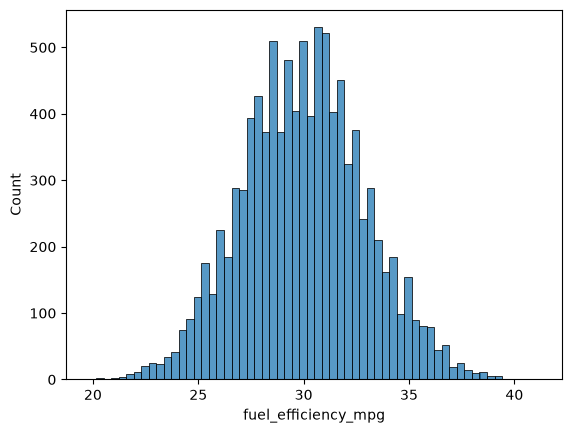

In [3]:
# Goal of this project is to create a regression model for predicting car fuel efficiency 'fuel_efficiency_mpg'

# Plot a histogram of this column
sns.histplot(cars.fuel_efficiency_mpg)
# Histogram has an approximate bell curve / normal distribution. Seems to be centered around 30 mpg.
# This distribution does not have a long tail.

In [4]:
# Question 1
# Use only the following columns:
# 'engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg'
# There's one column with missing values. What is it?

# First let's save only the requested columns to cars_one
cars_one = cars[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]

# Save the names of the features to a variable called features and the name of the target variable to a variable called target
features = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
target = ['fuel_efficiency_mpg']

# Now check missing values
cars_one.isnull().sum()
# horsepower is the only one with missing values

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [5]:
# Question 2
# What's the median (50% percentile) for variable 'horsepower'?
cars_one.horsepower.describe()
# The median is 254 mpg.

count    9123.000000
mean      254.446016
std        22.844613
min       171.000000
25%       239.000000
50%       254.000000
75%       270.000000
max       334.000000
Name: horsepower, dtype: float64

In [6]:
# Define linear regression function train_linear_regression from the lectures.
# This function takes feature matrix X and target vector y and returns the linear regression model weights w.
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]

In [7]:
# Define function to compute RMSE.
# Takes y_pred and y_actual and returns the RMSE
def rmse(y_pred, y_actual):
    assert len(y_pred) == len(y_actual)
    mse = np.mean((y_pred - y_actual) ** 2)
    return np.sqrt(mse)

In [8]:
# Splitting of the data into training/validation/testing is required for future questions.
# For Q5, repeat the same block with each listed seed. For Q6, use seed 9.

# To make this repeatable, we'll make it a function called df_split
# It takes a data frame split and a number seed.
# For this exercise we always do a 60/20/20 split so we can hardcode that for now.
# Returns an array with three elements: training data, validation data, then testing data
def df_split(df, seed):
    # Get size of each split
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test
    # Shuffle the indices
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)
    # Split the data into training set, validation set, and testing set
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    # Return df_train, df_val, and df_test
    return df_train, df_val, df_test

In [9]:
# Question 3
# We need to deal with missing values for the column from Q1.
# We have two options: fill it with 0 or with the mean of this variable.
# Try both options. For each, train a linear regression model without regularization using the code from the lessons.
# For computing the mean, use the training only!
# Use the validation dataset to evaluate the models and compare the RMSE of each option.
# Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release.
# Which option gives better RMSE?
# With 0, With mean, or are Both equally good?

# Split the data with seed 42 as instructed.
split_three_one = df_split(cars_one, 42)
df_train, df_val, df_test = split_three_one

# Let's start by saving the original horsepower columns for future reference
horsepower_train = df_train.horsepower
horsepower_val = df_val.horsepower

# Get the mean of the training set's horsepower column for future use
horsepower_train_mean = np.mean(df_train.horsepower)

In [10]:
# Question 3.1

# Fill missing values of horsepower with zeroes.
df_train.horsepower = df_train.horsepower.fillna(0)
df_val.horsepower = df_val.horsepower.fillna(0)

# Extract X_train and y_train
X_train = df_train[features].values
y_train = df_train[target].values

# Get the linear regression model parameters by calling train_linear_regression on X_train and y_train
w0, w = train_linear_regression(X_train, y_train)
w0, w

(array([-153.88496188]),
 array([[-1.51505520e-03],
        [-4.74024794e-06],
        [-3.95418397e-03],
        [ 1.02146785e-01]]))

<Axes: ylabel='Count'>

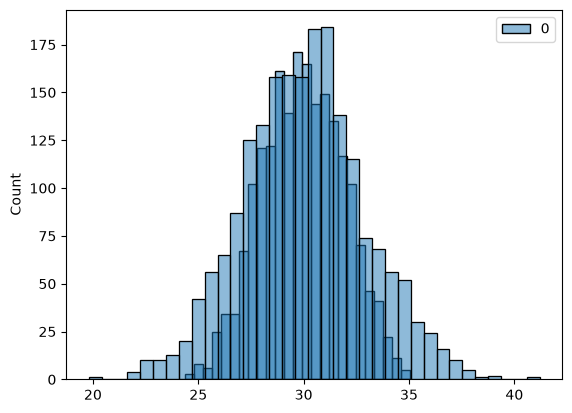

In [11]:
# Question 3.1

# Now we validate these parameters using the validation set.
# First, extract X_val and y_val
X_val = df_val[features].values
y_val = df_val[target].values

# Next, get predictions for y_val
y_pred = w0 + X_val.dot(w)

# Plot y_val and y_pred to see differences in distribution
sns.histplot(y_pred)
sns.histplot(y_val)
# See that they overlap heavily. Predictions seem to be pretty good.

In [12]:
# Question 3.1
# Calculate RMSE using the validation data
round(rmse(y_val, y_pred), 3)
# Get RMSE of appx 2.205

np.float64(2.205)

In [13]:
# Question 3.2

# This time, fill missing horsepower values with the mean horsepower from the training data that we saved earlier
df_train.horsepower = horsepower_train.fillna(horsepower_train_mean)
df_val.horsepower = horsepower_val.fillna(horsepower_train_mean)

# Extract X_train and y_train
X_train = df_train[features].values
y_train = df_train[target].values

# Get the linear regression model parameters by calling train_linear_regression on X_train and y_train
w0, w = train_linear_regression(X_train, y_train)
w0, w

(array([-153.29645639]),
 array([[-0.00102386],
        [-0.00648622],
        [-0.00388828],
        [ 0.10197897]]))

<Axes: ylabel='Count'>

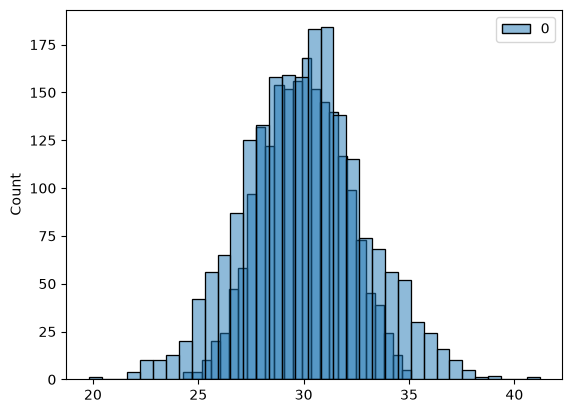

In [14]:
# Question 3.2

# Now we validate these parameters using the validation set.
# First, extract X_val and y_val
X_val = df_val[features].values
y_val = df_val[target].values

# Next, get predictions for y_val
y_pred = w0 + X_val.dot(w)

# Plot y_val and y_pred to see differences in distribution
sns.histplot(y_pred)
sns.histplot(y_val)
# See that they overlap heavily. Predictions seem to be pretty good.

In [16]:
# Question 3.2
# Calculate RMSE using the validation data
round(rmse(y_val, y_pred), 3)
# Get RMSE of appx 2.202
# A lower RMSE is better, so filling the missing values with the column mean results in a better validation RMSE

np.float64(2.202)

In [ ]:
# Question 4
# Now train a regularized linear regression.
# For this question, fill the NAs with 0.
# Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
# Use RMSE to evaluate the model on the validation dataset.
# Round the RMSE scores to 4 decimal digits. 
# This keeps the small but real regularization differences visible instead of turning several choices into a tie.
# Which r gives the best RMSE?
# If there is a tie, choose the lowest value of r.

# Define r
r = [0, 0.01, 0.1, 1, 5, 10, 100]

In [ ]:
# Question 5
# Let's find out how selecting the seed influences our score.
# Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
# For each seed, do the train/validation/test split with 60%/20%/20% distribution.
# Fill the missing values with 0 and train a model without regularization.
# For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
#What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
#Round the result to 3 decimal digits (round(std, 3))

# Start by defining the seeds vector with all the seeds to iterate through.
seeds = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

# Next define an NumPy array to store all the RMSE scores from each iteration. Call it scores. Has size 10.
scores = np.array(np.zeros(10))
scores

In [ ]:
# Now for each seed, repeat the process from question 3.
# Store the RMSE scores in the scores array.